**IMPORT LIBRARIES**

In [105]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppresses all warning messages

import numpy as np
import joblib
import random
import pandas as pd 
import matplotlib.pyplot as plt 
import tensorflow as tf 


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


**REPRODUCIBILITY**

In [106]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

**CREATE OUTPUT DIRECTORIES**

In [107]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../result", exist_ok=True)

**LOAD DATASET**

In [108]:
df = pd.read_csv("../data/Churn_Modelling.csv")

print("\nDataset loaded successfully.")

print("\nFirst 5 rows:")
print(df.head())


Dataset loaded successfully.

First 5 rows:
   RowNumber  CustomerId   Surname  ...  IsActiveMember EstimatedSalary Exited
0          1    15634602  Hargrave  ...               1       101348.88      1
1          2    15647311      Hill  ...               1       112542.58      0
2          3    15619304      Onio  ...               0       113931.57      1
3          4    15701354      Boni  ...               0        93826.63      0
4          5    15737888  Mitchell  ...               1        79084.10      0

[5 rows x 14 columns]


**EXPLORE DATASET**

In [109]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Exited"].value_counts())

print("\nTarget distribution percentage:")
print(
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
)


Dataset shape: (10000, 14)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

Missing values:
RowNumber          0
Cu

**DROP UNNECESSARY COLUMNS**

In [110]:
df = df.drop(
    ["RowNumber",
     "CustomerId",
     "Surname"],
     axis=1
)

**ENCODE GENDER**

In [111]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(
    df['Gender']
)

**ONE-HOT ENCODE GEOGRAPHY**

In [112]:
df = pd.get_dummies(
    df,
    columns=["Geography"],
    drop_first=True
)

for column in df.columns:

    if df[column].dtype == bool:

        df[column] == df[column].astype(int)

**SEPARATE FEATURES AND LABELS**

In [113]:
X = df.drop(
    "Exited",
    axis=1
)

y = df["Exited"]

print("\nFeature columns:")
print(X.columns.tolist())


print("\nNumber of features:", X.shape[1])


Feature columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']

Number of features: 11


**TRAIN-TEST SPLIT**

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

**VALIDATION SPLIT**

In [115]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

**DATASET SPLIT SHAPE**

In [116]:
print("\nDataset split:")

print(
    "Training:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Testing:",
    X_test.shape
)


Dataset split:
Training: (6400, 11)
Validation: (1600, 11)
Testing: (2000, 11)


**FEATURE SCALING**

In [117]:
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train = scaler.fit_transform(X_train)

# Transform validation and test using the same scaler
X_test = scaler.transform(X_test)

X_val = scaler.transform(X_val)

# Save scaler
joblib.dump(
    scaler,
    "../models/scaker.pkl"
)

['../models/scaker.pkl']

**MODEL BUILDING FUNCTION**

In [ ]:
def build_model(
    architecture=(64, 32, 16),
    learning_rate=0.001,
    optimizer_name="adam",
    dropout_rate=0.0,
    activation="relu"
):

    # Clear previous TensorFlow model
    tf.keras.backend.clear_session()

    # Create model
    model = tf.keras.Sequential()

    # Input layer
    model.add(
        tf.keras.layers.Input(
            shape=(X_train.shape[1] ,)
        )
    )

	# Hidden layers
    for units in architecture:

        model.add(
            tf.keras.layers.Dense(units=units, activation=activation)
        )

        # Add dropout if requested
        if dropout_rate > 0:

            model.add(
                tf.keras.layers.Dropout(dropout_rate)
            )
    
    # Output layer
    model.add(
        tf.keras.layers.Dense(
            units=1,
            activation="sigmoid"
        )
    )

    # OPTIMIZER SELECTION
    if optimizer_name == "adam":

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "sgd":

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    elif optimizer_name == "rmsprop":

        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    else:
        raise ValueError(
            f"Unsupported optimizer: {optimizer_name}"
        )


    # Compile Model
    model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
    )

    return model

    

**EXPERIMENT FUNCTION**

In [119]:
def run_experiment(
        experiment_name,
        architecture=(64, 32, 16),
        learning_rate=0.001,
        optimizer_name="adam",
        dropout_rate=0.0,
        activation="relu",
        batch_size=32,
        epochs=50
):
    print("\n")
    print("=" * 70)
    print("EXPERIMENT:", experiment_name)

    # Build model
    model = build_model(
        architecture=architecture,
        learning_rate=learning_rate,
        optimizer_name=optimizer_name,
        dropout_rate=dropout_rate,
        activation=activation,
    )

    # EARLY STOPPING
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    # TRAIN MODEL
    history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[
        early_stopping
    ],
    verbose=0
    )

    # VALIDATION PERFORMANCE
    val_loss, val_accuracy = model.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    # TEST PERFORMANCE
    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    # PREDICTIONS
    probabilities = model.predict(
        X_test,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # CLASSIFICATION METRICS
    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    precision = report[
        "weighted avg"
    ]["precision"]


    recall = report[
        "weighted avg"
    ]["recall"]


    f1 = report[
        "weighted avg"
    ]["f1-score"]

    # STORE RESULTS
    result = {

        "Experiment":
            experiment_name,

        "Optimizer":
            optimizer_name,

        "Learning Rate":
            learning_rate,

        "Architecture":
            str(architecture),

        "Activation":
            activation,

        "Dropout":
            dropout_rate,

        "Batch Size":
            batch_size,

        "Epochs":
            len(
                history.history["loss"]
            ),

        "Validation Accuracy":
            val_accuracy,

        "Test Accuracy":
            test_accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1 Score":
            f1,

        "Test Loss":
            test_loss

    }

    print(
        f"Validation Accuracy: "
        f"{val_accuracy:.4f}"
    )

    print(
        f"Test Accuracy: "
        f"{test_accuracy:.4f}"
    )

    print(
        f"F1 Score: "
        f"{f1:.4f}"
    )


    return model, history, result


**RESULTS STORAGE**

In [120]:
results = []

**BASELINE MODEL**

In [121]:
baseline_model, baseline_history, baseline_result = run_experiment(
    experiment_name="Baseline",
    architecture=(64, 32, 16),
    learning_rate=0.001,
    optimizer_name="adam",
    dropout_rate=0.0,
    activation="relu",
    batch_size=32,
    epochs=50
)

results.append(baseline_result)



EXPERIMENT: Baseline


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


**LEARNING RATE EXPERIMENTS**

In [122]:
learning_rates = [
    0.01,
    0.001,
    0.0001
]

for lr in learning_rates:

    model, experiment, result = run_experiment(
        experiment_name=f"Learning Rate {lr}",
        architecture=(64, 32, 16),
        learning_rate=lr,
        optimizer_name="adam",
        dropout_rate=0.0,
        activation="relu",
        batch_size=32,
        epochs=50
    )

    results.append(result)



EXPERIMENT: Learning Rate 0.01


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Learning Rate 0.001


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Learning Rate 0.0001


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


**OPTIMIZER EXPERIMENTS**

In [123]:
optimizers = [
    "adam",
    "sgd",
    "rmsprop"
]

for optimizer in optimizers:

    model, experiment, result = run_experiment(

        experiment_name=f"Optimizer {optimizer}",
        architecture=(64, 32, 16),
        learning_rate=0.001,
        optimizer_name=optimizer,
        dropout_rate=0.0,
        activation="relu",
        batch_size=32,
        epochs=50
    )

    results.append(result)



EXPERIMENT: Optimizer adam


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Optimizer sgd


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Optimizer rmsprop


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


**ARCHITECTURE EXPERIMENTS**

In [124]:
architectures = [

    (32, 16, 8),

    (64, 32, 16),

    (128, 64, 32),

    (128, 64, 32, 16)

]

for architecture in architectures:

    model, history, result = run_experiment(

        experiment_name=f"Architecture {architecture}",

        architecture=architecture,

        learning_rate=0.001,

        optimizer_name="adam",

        dropout_rate=0.0,

        activation="relu",

        batch_size=32,

        epochs=50

    )

    results.append(result)



EXPERIMENT: Architecture (32, 16, 8)


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Architecture (64, 32, 16)


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Architecture (128, 64, 32)


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Architecture (128, 64, 32, 16)


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


**BATCH SIZE EXPERIMENTS**

In [125]:
batch_sizes = [

    16,

    32,

    64,

    128

]

for batch_size in batch_sizes:

    model, experiment, result = run_experiment(
        experiment_name=f"Batch Size {batch_size}",

        architecture=(64, 32, 16),

        learning_rate=0.001,

        optimizer_name="adam",

        dropout_rate=0.0,

        activation="relu",

        batch_size=batch_size,

        epochs=50
)

    results.append(result)



EXPERIMENT: Batch Size 16


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Batch Size 32


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Batch Size 64


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (64, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Batch Size 128


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (128, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


**DROPOUT EXPERIMENTS**

In [126]:
dropout_rates = [

    0.0,

    0.2,

    0.3,

    0.5

]

for dropout in dropout_rates:

    model, experiment, result = run_experiment(

        experiment_name=f"Dropout {dropout}",

        architecture=(64, 32, 16),

        learning_rate=0.001,

        optimizer_name="adam",

        dropout_rate=dropout,

        activation="relu",

        batch_size=32,

        epochs=50
    )

    results.append(result)



EXPERIMENT: Dropout 0.0


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Dropout 0.2


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Dropout 0.3


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Dropout 0.5


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


**ACTIVATION FUNCTION EXPERIMENTS**

In [127]:
activations = [

    "relu",

    "tanh"

]

for activation in activations:

    model, history, result = run_experiment(

        experiment_name=f"Activation {activation}",

        architecture=(64, 32, 16),

        learning_rate=0.001,

        optimizer_name="adam",

        dropout_rate=0.2,

        activation=activation,

        batch_size=32,

        epochs=50

    )

    results.append(result)



EXPERIMENT: Activation relu


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


EXPERIMENT: Activation tanh


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation Accuracy: 0.2037
Test Accuracy: 0.2035
F1 Score: 0.0688


**CREATE RESULTS DATAFRAME**

In [128]:
results_df = pd.DataFrame(
    results
)

# Sort by validation accuracy
results_df = results_df.sort_values(
    by="Validation Accuracy",
    ascending=False

).reset_index(
    drop=True
)

**DISPLAY RESULTS**

In [129]:
print("\n")
print("=" * 70)
print("HYPERPARAMETER EXPERIMENT RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)




HYPERPARAMETER EXPERIMENT RESULTS
                    Experiment Optimizer  Learning Rate      Architecture Activation  Dropout  Batch Size  Epochs  Validation Accuracy  Test Accuracy  Precision  Recall  F1 Score  Test Loss
                      Baseline      adam         0.0010      (64, 32, 16)       relu      0.0          32      16              0.20375         0.2035   0.041412  0.2035   0.06882   0.341081
            Learning Rate 0.01      adam         0.0100      (64, 32, 16)       relu      0.0          32      12              0.20375         0.2035   0.041412  0.2035   0.06882   0.349268
           Learning Rate 0.001      adam         0.0010      (64, 32, 16)       relu      0.0          32      15              0.20375         0.2035   0.041412  0.2035   0.06882   0.342470
          Learning Rate 0.0001      adam         0.0001      (64, 32, 16)       relu      0.0          32      50              0.20375         0.2035   0.041412  0.2035   0.06882   0.339689
              

**SAVE RESULTS**

In [130]:
results_df.to_csv(
    "../result/experiment_results.csv",
    index=False
)

**SELECT BEST MODEL CONFIGURATION**

In [131]:
best_result = results_df.iloc[0]

print("\n")
print("=" * 70)
print("BEST CONFIGURATION")
print("=" * 70)


print(
    "Experiment:",
    best_result["Experiment"]
)

print(
    "Optimizer:",
    best_result["Optimizer"]
)

print(
    "Architecture:",
    best_result["Architecture"]
)

print(
    "Activation:",
    best_result["Activation"]
)

print(
    "Dropout:",
    best_result["Dropout"]
)

print(
    "Batch Size:",
    best_result["Batch Size"]
)

print(
    "Validation Accuracy:",
    f"{best_result['Validation Accuracy']:.4f}"
)





BEST CONFIGURATION
Experiment: Baseline
Optimizer: adam
Architecture: (64, 32, 16)
Activation: relu
Dropout: 0.0
Batch Size: 32
Validation Accuracy: 0.2037


**PARSE BEST PARAMETERS**

In [132]:
best_architecture = eval(
    best_result["Architecture"]
)

best_learning_rate = float(
    best_result["Learning Rate"]
)

best_optimizer = best_result[
    "Optimizer"
]

best_activation = best_result[
    "Activation"
]

best_dropout = float(
    best_result["Dropout"]
)

best_batch_size = int(
    best_result["Batch Size"]
)

**BUILD FINAL MODEL**

In [133]:
final_model = build_model(
    architecture=best_architecture,
    learning_rate=best_learning_rate,
    optimizer_name=best_optimizer,
    dropout_rate=best_dropout,
    activation=best_activation
)

**FINAL MODEL TRAINING**

In [134]:
final_early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

final_history = final_model.fit(

    X_train,

    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=100,

    batch_size=best_batch_size,

    callbacks=[
        final_early_stopping
    ],

    verbose=1
)

Epoch 1/100


d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2037 - loss: 0.4936 - val_accuracy: 0.2037 - val_loss: 0.4243
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2037 - loss: 0.4015 - val_accuracy: 0.2037 - val_loss: 0.3851
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2037 - loss: 0.3609 - val_accuracy: 0.2037 - val_loss: 0.3603
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2037 - loss: 0.3426 - val_accuracy: 0.2037 - val_loss: 0.3547
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2037 - loss: 0.3356 - val_accuracy: 0.2037 - val_loss: 0.3526
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2037 - loss: 0.3312 - val_accuracy: 0.2037 - val_loss: 0.3522
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2037 - loss: 0.3278 - val_accuracy: 0.2037 - val_loss: 0.3520
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2037 - loss: 0.3250 - val_accuracy: 0.2037

**FINAL TEST EVALUATION**

In [135]:
final_loss, final_accuracy = final_model.evaluate(

    X_test,

    y_test,

    verbose=0

)

print("\n")
print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(
    f"Test Loss: {final_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{final_accuracy:.4f}"
)

print(
    f"Test Accuracy: "
    f"{final_accuracy * 100:.2f}%"
)

d:\Neural_networks\myenv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(




FINAL MODEL PERFORMANCE
Test Loss: 0.3442
Test Accuracy: 0.2035
Test Accuracy: 20.35%


**FINAL PREDICTIONS**

In [136]:
final_probabilities = final_model.predict(

    X_test,

    verbose=0

).ravel()


final_predictions = (

    final_probabilities >= 0.5

).astype(int)

**CLASSIFICATION REPORT**

In [137]:
print("\n")
print("=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

print(

    classification_report(

        y_test,

        final_predictions,

        target_names=[
            "Stayed",
            "Churned"
        ],

        zero_division=0

    )

)



FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.00      0.00      0.00      1593
     Churned       0.20      1.00      0.34       407

    accuracy                           0.20      2000
   macro avg       0.10      0.50      0.17      2000
weighted avg       0.04      0.20      0.07      2000



**CONFUSION MATRIX**

In [138]:
cm = confusion_matrix(

    y_test,

    final_predictions

)


print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[   0 1593]
 [   0  407]]


**CONFUSION MATRIX VISUALIZATION**

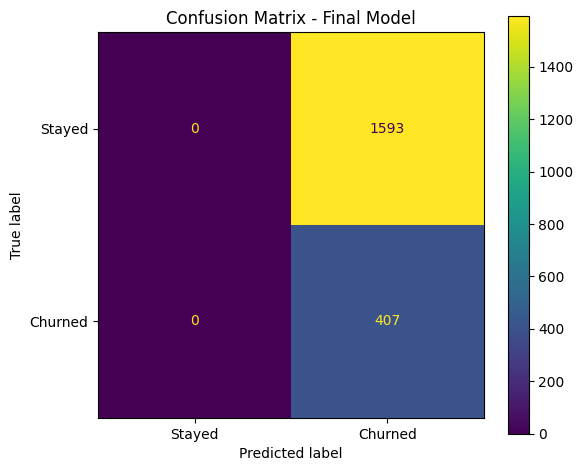

In [141]:
disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Stayed",
        "Churned"
    ]

)


fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp.plot(
    ax=ax
)

plt.title(
    "Confusion Matrix - Final Model"
)

plt.tight_layout()

plt.savefig(

    "../result/confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

**FINAL ACCURACY CURVE**

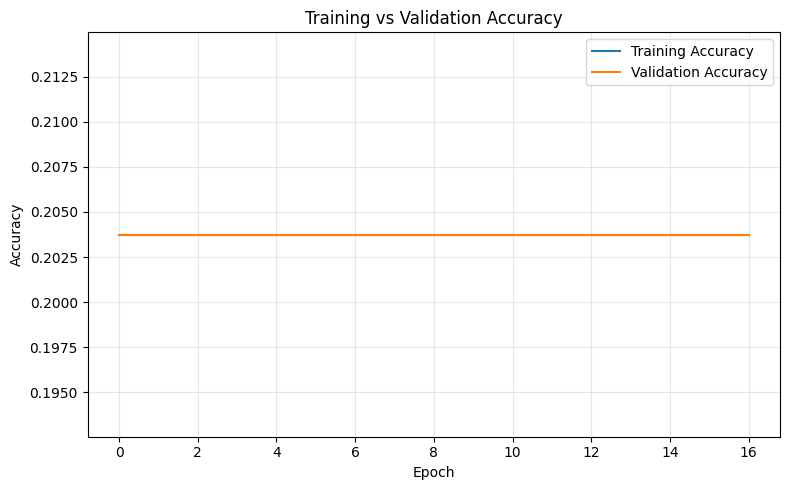

In [143]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(

    final_history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    final_history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    "../result/accuracy_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

**FINAL LOSS CURVE**

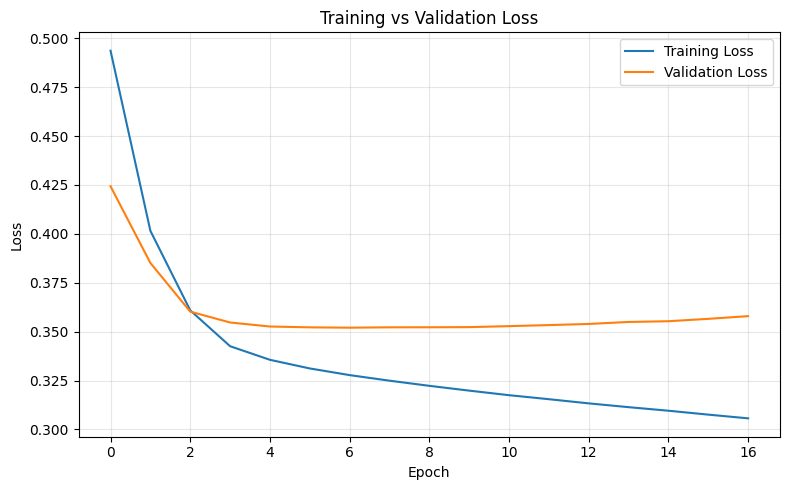

In [145]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(

    final_history.history["loss"],

    label="Training Loss"

)

plt.plot(

    final_history.history["val_loss"],

    label="Validation Loss"

)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    "../result/loss_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

**HYPERPARAMETER COMPARISON**

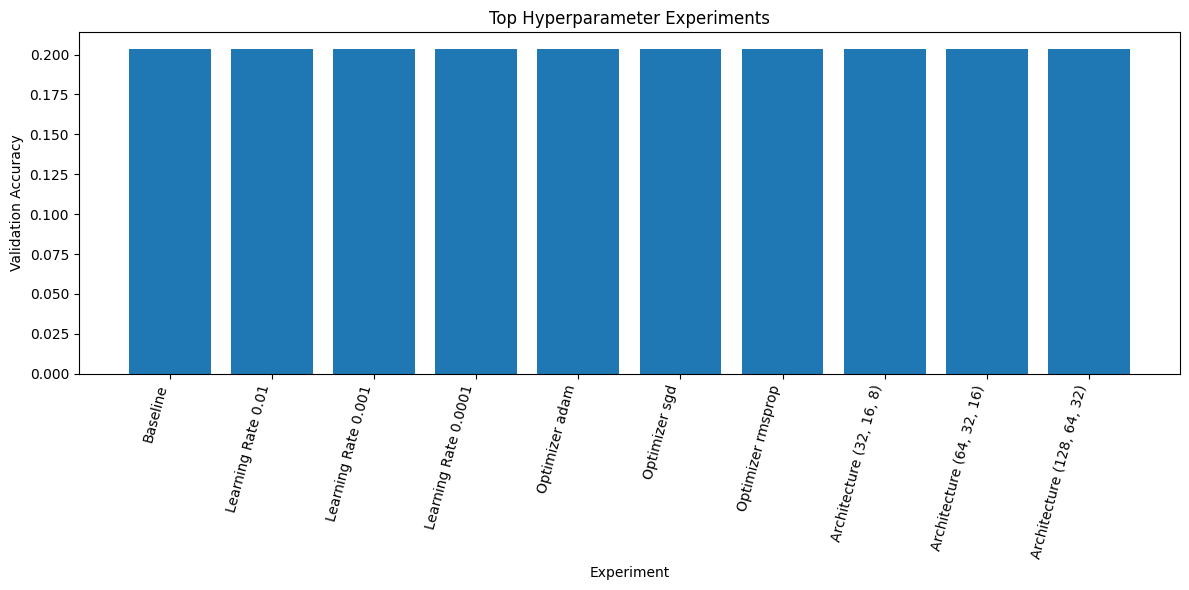

In [147]:
top_results = results_df.head(10)


plt.figure(
    figsize=(12, 6)
)

plt.bar(

    top_results["Experiment"],

    top_results["Validation Accuracy"]

)

plt.xticks(

    rotation=75,

    ha="right"

)

plt.ylabel(
    "Validation Accuracy"
)

plt.xlabel(
    "Experiment"
)

plt.title(
    "Top Hyperparameter Experiments"
)

plt.tight_layout()

plt.savefig(

    "../result/hyperparameter_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

**BASELINE VS FINAL MODEL**

In [148]:
baseline_accuracy = baseline_result[
    "Test Accuracy"
]


improvement = (

    final_accuracy -
    baseline_accuracy

)


print("\n")
print("=" * 70)
print("BASELINE VS TUNED MODEL")
print("=" * 70)

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Tuned Accuracy: "
    f"{final_accuracy:.4f}"
)

print(
    f"Improvement: "
    f"{improvement:.4f}"
)

print(
    f"Improvement: "
    f"{improvement * 100:.2f} percentage points"
)



BASELINE VS TUNED MODEL
Baseline Accuracy: 0.2035
Tuned Accuracy: 0.2035
Improvement: 0.0000
Improvement: 0.00 percentage points


**SAVE FINAL MODEL**

In [149]:
final_model.save(
    "../models/best_churn_model.keras"
)

**SAVE BEST CONFIGURATION**

In [151]:
best_configuration = pd.DataFrame([

    {

        "Architecture":
            str(best_architecture),

        "Optimizer":
            best_optimizer,

        "Learning Rate":
            best_learning_rate,

        "Activation":
            best_activation,

        "Dropout":
            best_dropout,

        "Batch Size":
            best_batch_size,

        "Test Accuracy":
            final_accuracy

    }

])


best_configuration.to_csv(

    "../result/best_model_configuration.csv",

    index=False

)

**SAMPLE CUSTOMER PREDICTION**

In [152]:
print("\n")
print("=" * 70)
print("SAMPLE CUSTOMER PREDICTION")
print("=" * 70)


sample_customer = pd.DataFrame({

    "CreditScore": [650],

    "Gender": [1],

    "Age": [40],

    "Tenure": [5],

    "Balance": [100000],

    "NumOfProducts": [2],

    "HasCrCard": [1],

    "IsActiveMember": [1],

    "EstimatedSalary": [60000],

    "Geography_Germany": [0],

    "Geography_Spain": [0]

})

# Ensure identical column order
sample_customer = sample_customer[
    X.columns
]


# Scale sample
sample_scaled = scaler.transform(
    sample_customer
)


# Predict
churn_probability = (

    final_model.predict(

        sample_scaled,

        verbose=0

    )[0][0]

)


print(
    f"Churn Probability: "
    f"{churn_probability:.2%}"
)


if churn_probability >= 0.5:

    print(
        "Prediction: Customer is likely to CHURN."
    )

else:

    print(
        "Prediction: Customer is likely to STAY."
    )





SAMPLE CUSTOMER PREDICTION
Churn Probability: 100.00%
Prediction: Customer is likely to CHURN.


**FINAL PROJECT SUMMARY**

In [153]:
print("\n")
print("=" * 70)
print("PROJECT COMPLETED")
print("=" * 70)

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy:.2%}"
)

print(
    f"Final Tuned Accuracy: "
    f"{final_accuracy:.2%}"
)

print(
    f"Improvement: "
    f"{improvement * 100:.2f} percentage points"
)

print("\nGenerated files:")

print(
    "../models/baseline_model.keras"
)

print(
    "../models/best_churn_model.keras"
)

print(
    "../models/scaler.pkl"
)

print(
    "../result/experiment_results.csv"
)

print(
    "../result/best_model_configuration.csv"
)

print(
    "../result/confusion_matrix.png"
)

print(
    "../result/accuracy_curve.png"
)

print(
    "../result/loss_curve.png"
)

print(
    "../result/hyperparameter_comparison.png"
)

print("\nAll experiments completed successfully.")



PROJECT COMPLETED
Baseline Accuracy: 20.35%
Final Tuned Accuracy: 20.35%
Improvement: 0.00 percentage points

Generated files:
../models/baseline_model.keras
../models/best_churn_model.keras
../models/scaler.pkl
../result/experiment_results.csv
../result/best_model_configuration.csv
../result/confusion_matrix.png
../result/accuracy_curve.png
../result/loss_curve.png
../result/hyperparameter_comparison.png

All experiments completed successfully.
